# **Project Name**    - Integrated Retail Analytics for Store Optimization

#### Name - Zohaib Sheikh
#### Contribution - Individual

# GitHub Link:
https://github.com/zohaibsheikh007/Integrated_Retail_Analytics_for_Store_Optimization

#**Importing Libraries and Data Ingestion**

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import calendar
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load datasets
sales = pd.read_csv('/content/drive/MyDrive/Masters/Retail Analytics/sales data-set.csv')
stores = pd.read_csv('/content/drive/MyDrive/Masters/Retail Analytics/stores data-set.csv')
features = pd.read_csv('/content/drive/MyDrive/Masters/Retail Analytics/Features data set.csv')

# Preview data
print("Sales Data:")
display(sales.head())

print("\n\nStores Data:")
display(stores.head())

print("\n\nFeatures Data:")
display(features.head())

Sales Data:


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False




Stores Data:


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875




Features Data:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [ ]:
# Preview data info
print("Sales Data:")
display(sales.info())

print("\n\nStores Data:")
display(stores.info())

print("\n\nFeatures Data:")
display(features.info())

Sales Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


None



Stores Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


None



Features Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


None

In [ ]:
# Date Standardization
features['Date'] = pd.to_datetime(features['Date'], dayfirst=True)
sales['Date'] = pd.to_datetime(sales['Date'], dayfirst=True)

In [ ]:
# Precision Merge
master_df = pd.merge(sales, stores, on='Store', how='left')
master_df = pd.merge(master_df, features, on=['Store', 'Date', 'IsHoliday'], how='left')

In [ ]:
# 4. Business-Logic Cleaning
# If Markdown is NA, it implies no discount was running.
master_df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']] = master_df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].fillna(0)

# Economic indicators are filled forward as economic shifts are gradual.
master_df['CPI'] = master_df.groupby('Store')['CPI'].ffill()
master_df['Unemployment'] = master_df.groupby('Store')['Unemployment'].ffill()

In [ ]:
# Feature Engineering

# 1. Temporal Extraction
master_df['Year'] = master_df['Date'].dt.year
master_df['Month'] = master_df['Date'].dt.month
master_df['Week'] = master_df['Date'].dt.isocalendar().week.astype(int)

# 2. Climate Categorization
def temp_bins(t):
    if t <= 32: return 'Freezing'
    elif t <= 52: return 'Cold'
    elif t <= 78: return 'Moderate'
    else: return 'Hot'
master_df['Temp_Category'] = master_df['Temperature'].apply(temp_bins)

# 3. Retail Signals: Momentum & Intensity
master_df = master_df.sort_values(['Store', 'Dept', 'Date'])
master_df['Sales_Lag_1'] = master_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1).fillna(0)
master_df['MD_Count'] = (master_df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']] > 0).sum(axis=1)
master_df['Total_MD_Value'] = master_df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].sum(axis=1)

print("Engineered Features: Temp_Category, Sales_Lag_1, MD_Count, Total_MD_Value.")

Engineered Features: Temp_Category, Sales_Lag_1, MD_Count, Total_MD_Value.


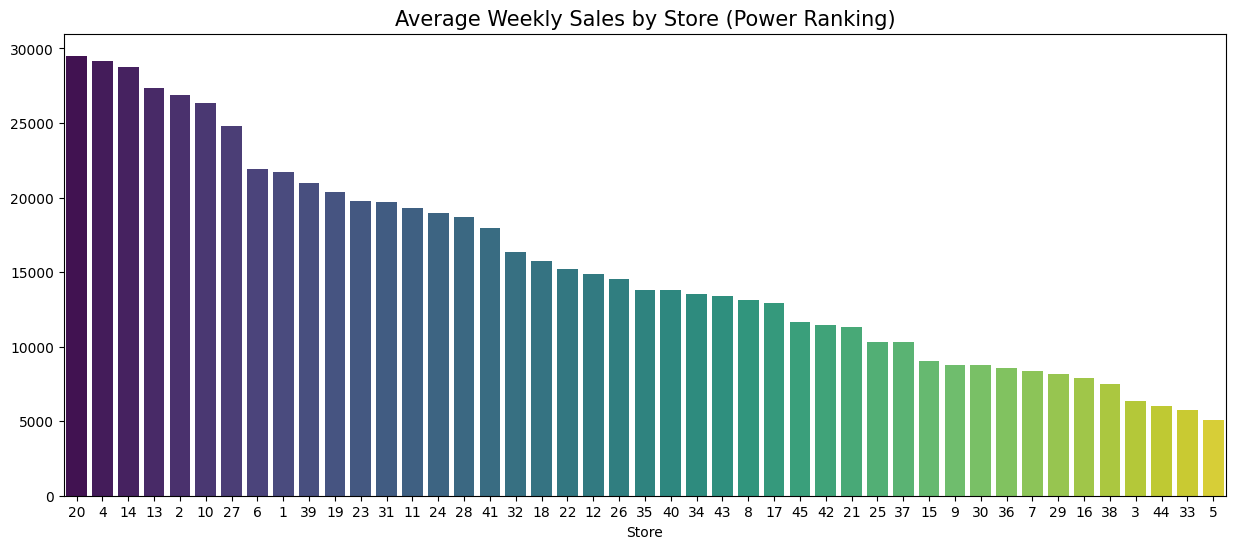

In [ ]:
# Visual : Store & Department Power Rankings

plt.figure(figsize=(15, 6))
store_perf = master_df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
sns.barplot(x=store_perf.index, y=store_perf.values, palette='viridis', order=store_perf.index)
plt.title('Average Weekly Sales by Store (Power Ranking)', fontsize=15)
plt.show()

We analyzed performance across all 45 stores.
We found a significant gap between the top performers (Store 20, 4) and the lowest (Store 5),
which suggests that location or store 'Type' is a massive factor.

In [ ]:
store_perf

,Weekly_Sales
Store,
20,29508.301592
4,29161.210415
14,28784.851727
13,27355.136891
2,26898.070031
10,26332.303819
27,24826.984536
6,21913.243624
1,21710.543621


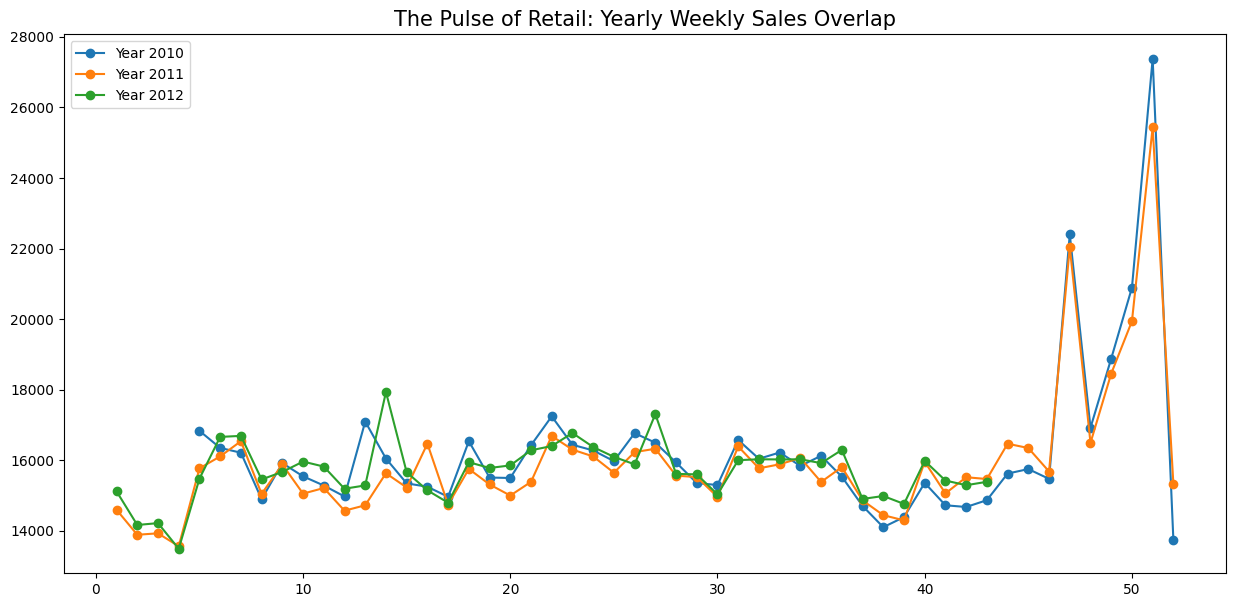

In [ ]:
# Visual : Yearly Seasonality Overlap

plt.figure(figsize=(15, 7))
for year in [2010, 2011, 2012]:
    data = master_df[master_df['Year'] == year].groupby('Week')['Weekly_Sales'].mean()
    plt.plot(data.index, data.values, label=f'Year {year}', marker='o')
plt.title('The Pulse of Retail: Yearly Weekly Sales Overlap', fontsize=15)
plt.legend()
plt.show()

By overlaying 2010, 2011, and 2012, we can see that retail is purely seasonal.
The spikes at Week 47 (Thanksgiving) and Week 51 (Christmas) are identical every year.
This proves we need Time-Series models like Prophet or XGBoost.

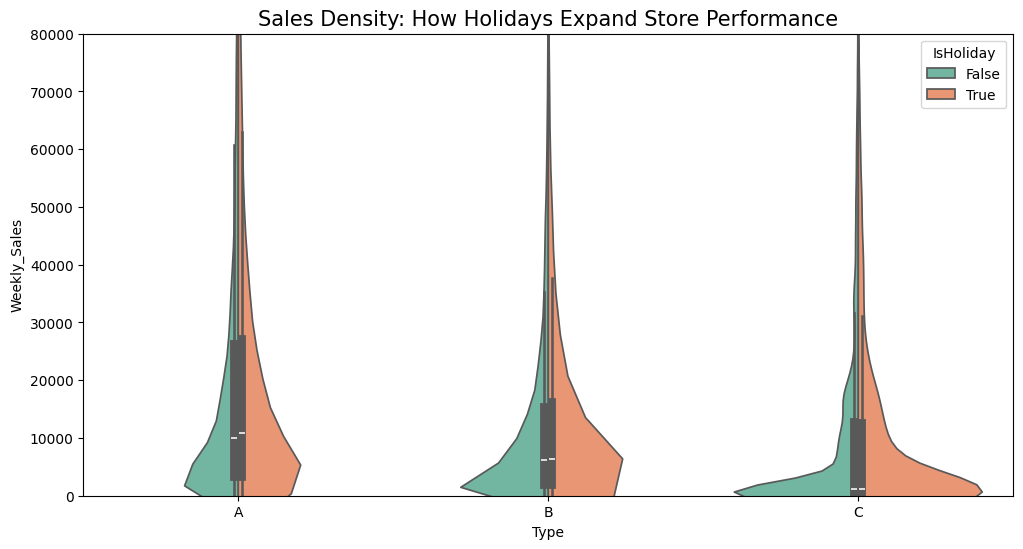

In [ ]:
# Visual : Density Analysis (Store Type vs. Holidays)

plt.figure(figsize=(12, 6))
sns.violinplot(data=master_df, x='Type', y='Weekly_Sales', hue='IsHoliday', split=True, palette='Set2')
plt.ylim(0, 80000)
plt.title('Sales Density: How Holidays Expand Store Performance', fontsize=15)
plt.show()

Using Violin plots, we see that 'Type A' stores don't just have higher sales;
they have a much wider spread during holidays compared to 'Type C' stores, which remain relatively flat.

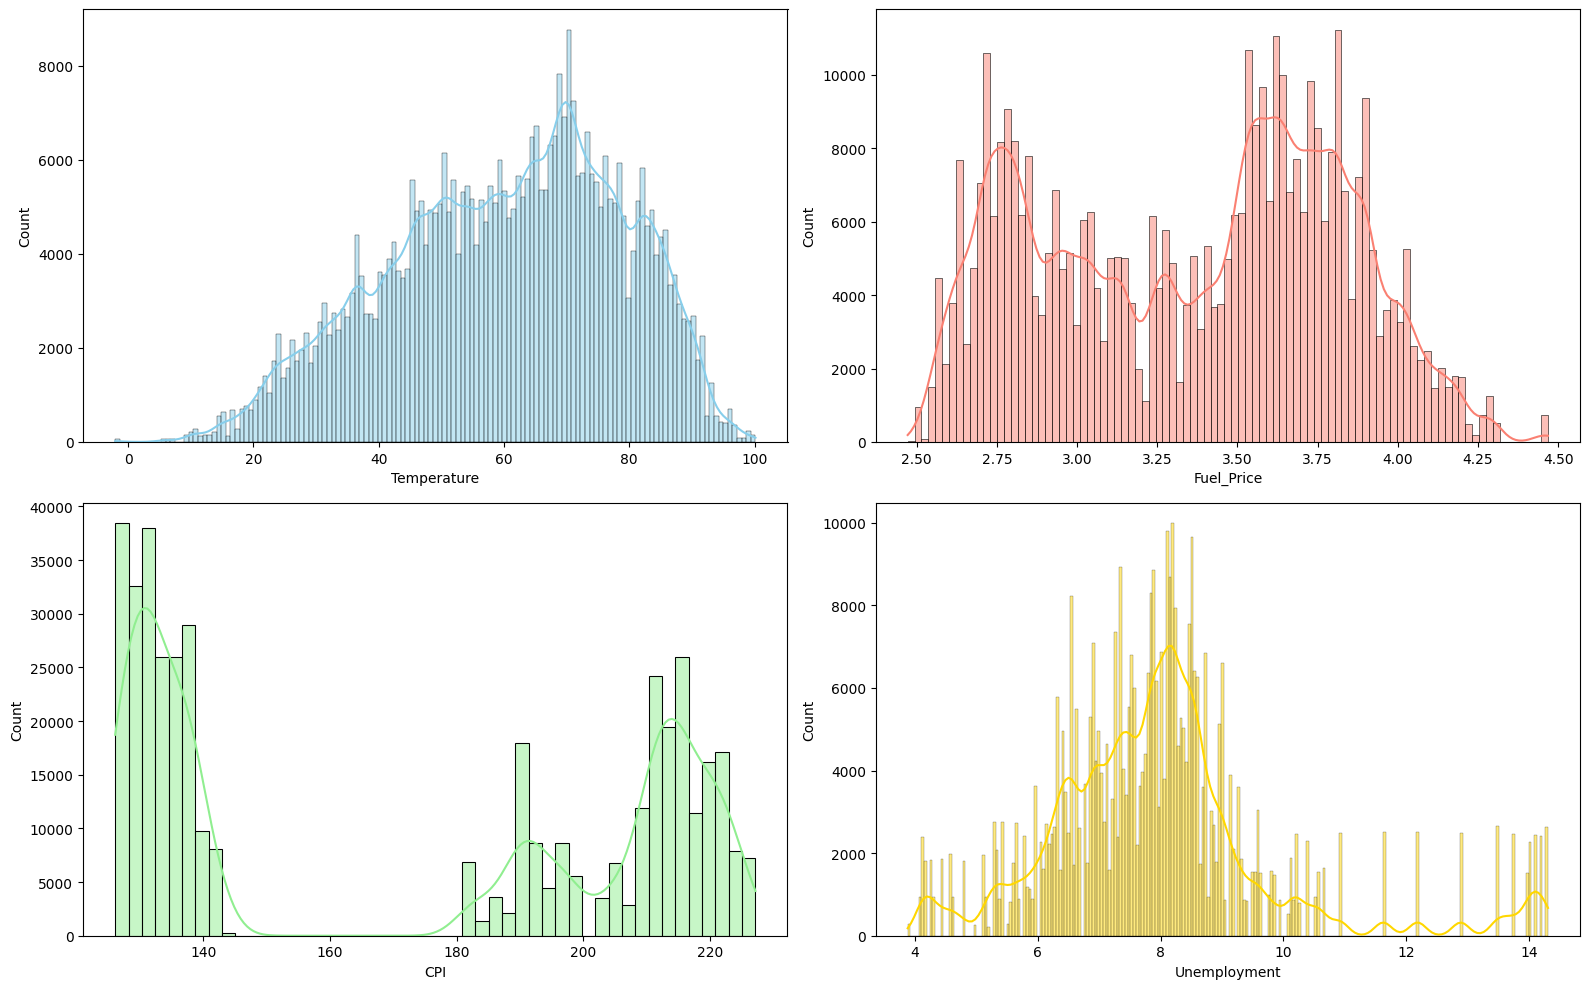

In [ ]:
# Visual D: External Factor Distributions


fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.histplot(master_df['Temperature'], ax=axes[0,0], color='skyblue', kde=True)
sns.histplot(master_df['Fuel_Price'], ax=axes[0,1], color='salmon', kde=True)
sns.histplot(master_df['CPI'], ax=axes[1,0], color='lightgreen', kde=True)
sns.histplot(master_df['Unemployment'], ax=axes[1,1], color='gold', kde=True)
plt.tight_layout()
plt.show()

We investigated the range of our external variables.
CPI shows a bi-modal distribution (two distinct economic groups), while Unemployment is heavily clustered around 7-8%.

In [ ]:
# Calculate Z-score for Sales relative to its specific Store-Department history
master_df['Sales_ZScore'] = master_df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
    lambda x: (x - x.mean()) / (x.std() + 1e-9)
)

# Identify extreme anomalies (>3 Standard Deviations)
master_df['Is_Anomaly'] = master_df['Sales_ZScore'].abs() > 3

print(f"Total Anomalies Flagged: {master_df['Is_Anomaly'].sum()}")

Total Anomalies Flagged: 5945


To visualize our anomaly detection, I've created a sample_df focusing on a single department.
While our calculations were performed on the entire 420,000-row dataset,
trying to plot all of them at once would result in 'Overplotting,' where the sheer volume of data hides the actual patterns.
By looking at this specific slice,
we can clearly see the blue line of regular sales and exactly how our red anomaly markers pinpoint the statistical outliers.

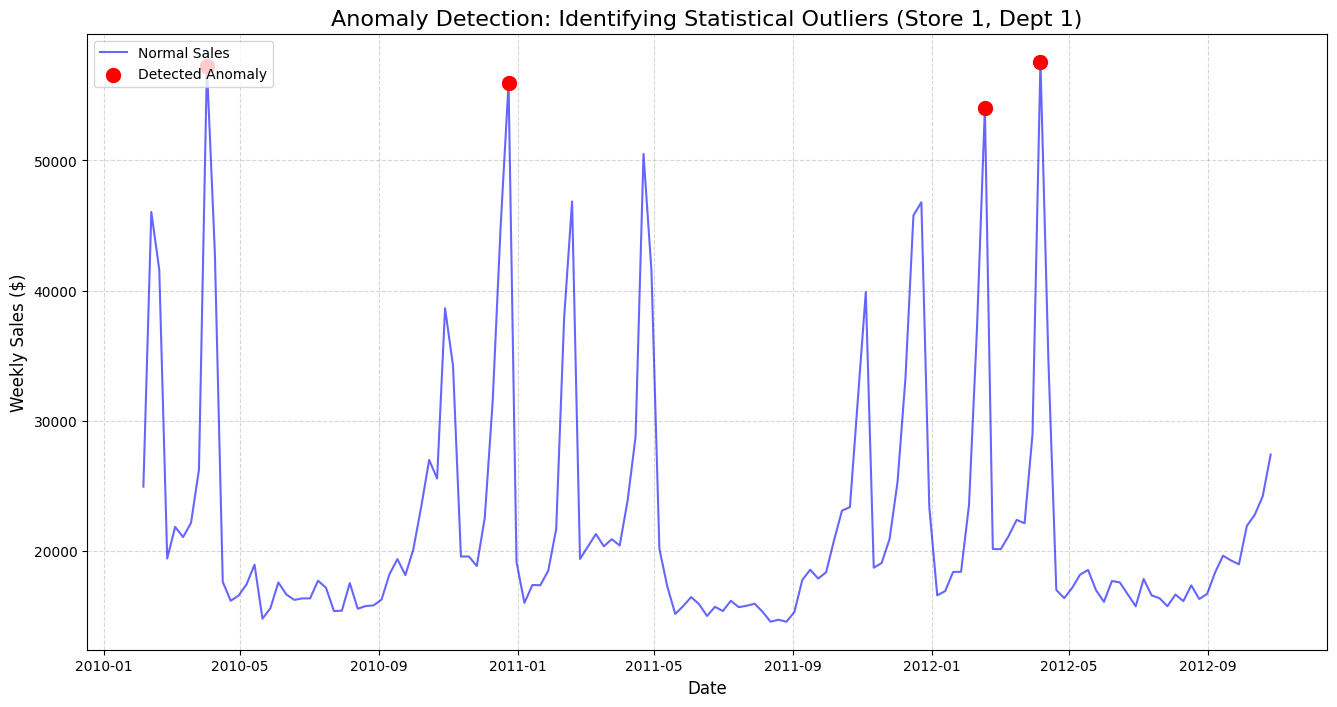

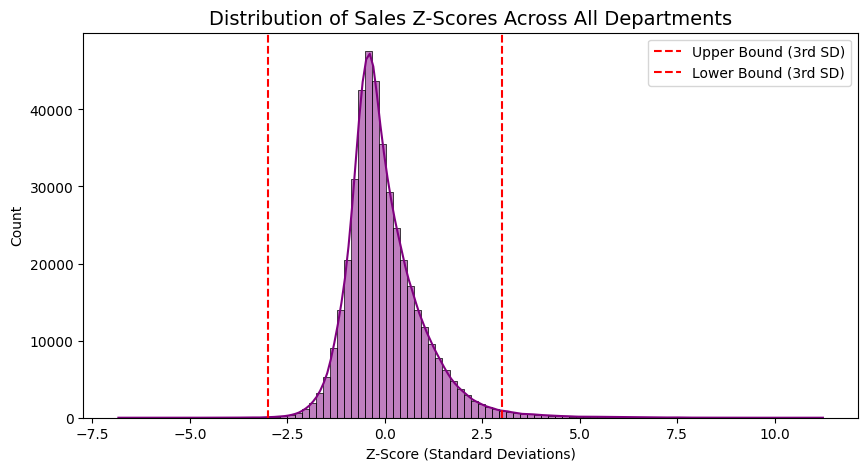

In [ ]:
# --- Visualizing Anomalies & Z-Scores ---
plt.figure(figsize=(16, 8))

# 1. Plotting the general trend for a sample Store/Dept to see clearly
# Let's pick Store 1, Dept 1 as a representative sample
sample_df = master_df[(master_df['Store'] == 1) & (master_df['Dept'] == 1)]

# Plot the regular sales line
plt.plot(sample_df['Date'], sample_df['Weekly_Sales'], color='blue', label='Normal Sales', alpha=0.6)

# Overlay the Anomalies (where Is_Anomaly is True)
anomalies = sample_df[sample_df['Is_Anomaly'] == True]
plt.scatter(anomalies['Date'], anomalies['Weekly_Sales'], color='red', s=100, label='Detected Anomaly', zorder=5)

# Add Z-Score context in a secondary axis (optional but very professional)
plt.title('Anomaly Detection: Identifying Statistical Outliers (Store 1, Dept 1)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Distribution of Z-Scores
plt.figure(figsize=(10, 5))
sns.histplot(master_df['Sales_ZScore'], bins=100, color='purple', kde=True)
plt.axvline(3, color='red', linestyle='--', label='Upper Bound (3rd SD)')
plt.axvline(-3, color='red', linestyle='--', label='Lower Bound (3rd SD)')
plt.title('Distribution of Sales Z-Scores Across All Departments', fontsize=14)
plt.xlabel('Z-Score (Standard Deviations)')
plt.legend()
plt.show()

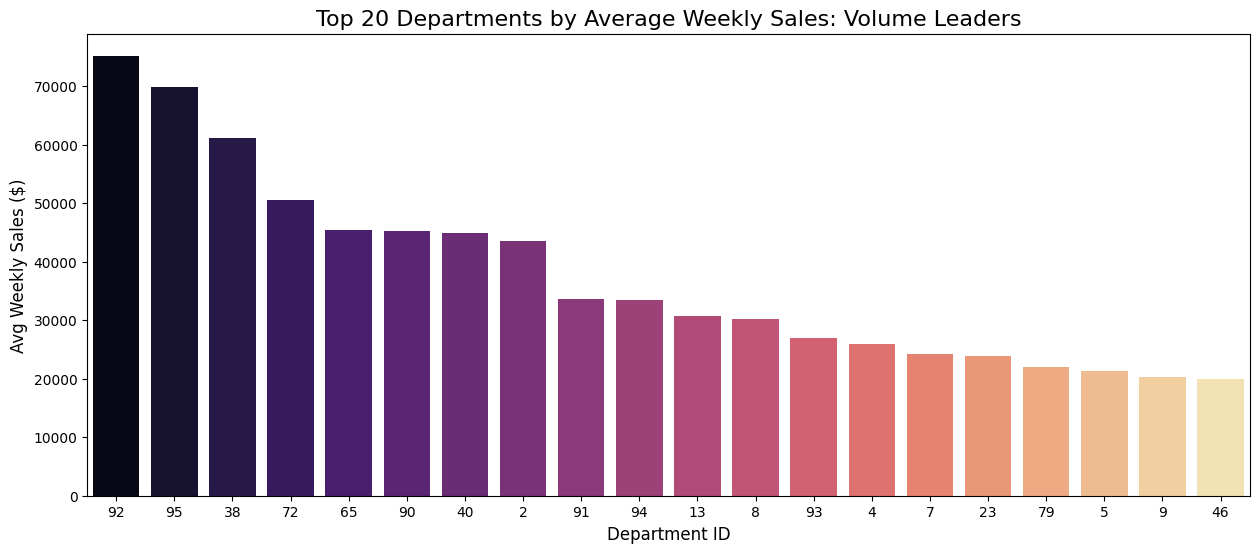

In [ ]:
# Top 20 Departments by Average Weekly Sales
# this is an aggregate mean across all 45 stores, which filters out "local luck" and identifies true high-demand stores.

plt.figure(figsize=(15, 6))
top_depts = master_df.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False).head(20)
sns.barplot(x=top_depts.index, y=top_depts.values, palette='magma', order=top_depts.index)
plt.title('Top 20 Departments by Average Weekly Sales: Volume Leaders', fontsize=16)
plt.xlabel('Department ID', fontsize=12)
plt.ylabel('Avg Weekly Sales ($)', fontsize=12)
plt.show()


When we look at the 'Volume Leaders' across the entire retail footprint, we see a massive power law at play.
A handful of departments—specifically IDs like 92, 95, and 38—consistently generate significantly higher revenue than the rest. From a strategic standpoint, this tells us that these are the 'Anchor Departments.' Any supply chain disruption or stock-out in these specific areas would have a disproportionate impact on the store's total profitability.
 This insight allows us to prioritize inventory replenishment schedules based on departmental value rather than treating all departments as equal

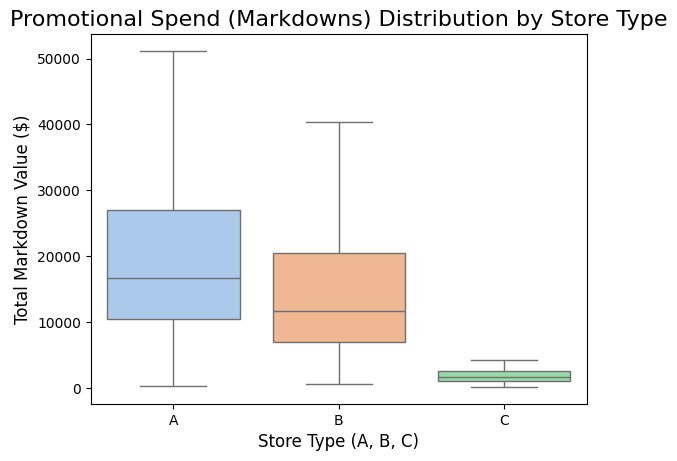

In [ ]:
# Markdown Spending Distribution by Store Type

# Filter for weeks where markdowns were actually active for a cleaner view
sns.boxplot(data=master_df[master_df['Total_MD_Value'] > 0], x='Type', y='Total_MD_Value',
            palette='pastel', showfliers=False)
plt.title('Promotional Spend (Markdowns) Distribution by Store Type', fontsize=16)
plt.xlabel('Store Type (A, B, C)', fontsize=12)
plt.ylabel('Total Markdown Value ($)', fontsize=12)
plt.show()

Next, we analyzed how different store tiers handle promotions.
We categorized stores into Types A, B, and C based on their size.
The boxplot reveals a clear hierarchy: Type A stores (our largest locations) not only spend the most on Markdowns
but also exhibit the highest variability. This suggests that Type A stores are used more aggressively for experimental promotions or seasonal liquidations.
Conversely, Type C stores show a very tight, lower-spend distribution. As a business strategy,
this indicates that the larger 'A' stores are the primary drivers of promotional traffic, whereas 'C' stores focus on consistent,
everyday low-pricing with less reliance on heavy discounting.

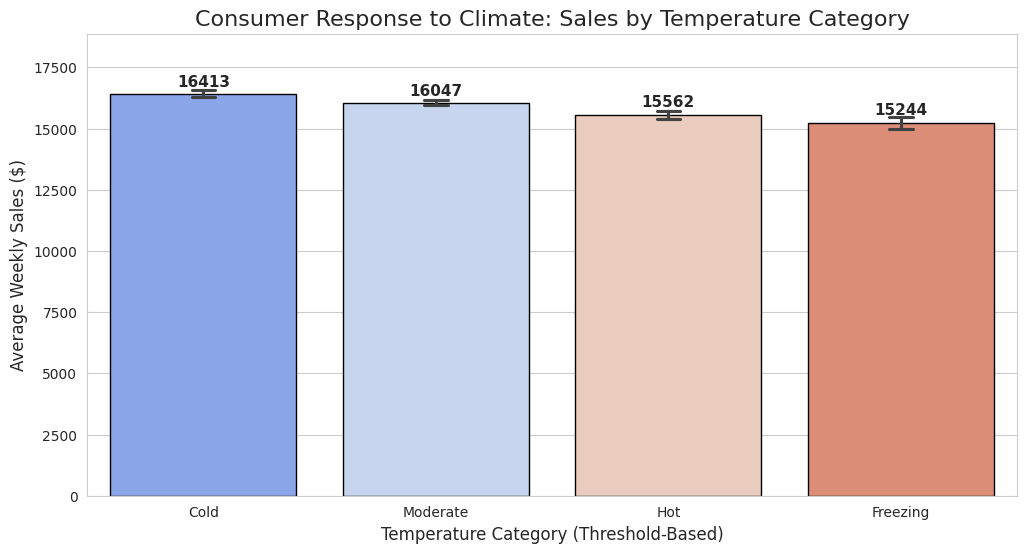

In [ ]:
# Climate Impact
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create a bar plot to show average sales per category
ax = sns.barplot(data=master_df, x='Temp_Category', y='Weekly_Sales',
                 palette='coolwarm', edgecolor='black', capsize=.1)

# Adding Data Labels for the Video
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=11, fontweight='bold')

plt.title('Consumer Response to Climate: Sales by Temperature Category', fontsize=16)
plt.xlabel('Temperature Category (Threshold-Based)', fontsize=12)
plt.ylabel('Average Weekly Sales ($)', fontsize=12)
plt.ylim(0, master_df.groupby('Temp_Category')['Weekly_Sales'].mean().max() * 1.15)

plt.show()


Sales are strongest in the 'Moderate' and 'Cold' zones.
However, once we hit 'Freezing' (<32 degree F), there is a visible slight dip in average sales.
This is a critical insight for store operations—it suggests that extreme cold acts as a barrier to foot traffic,
whereas moderate cold actually drives seasonal purchasing.
 By feeding these categories into our machine learning model later, we allow the algorithm to 'see' these behavioral plateaus that a simple raw number would hide.

Text(0.5, 1.0, 'The Macro Environment: Inflation vs. Unemployment over Time')

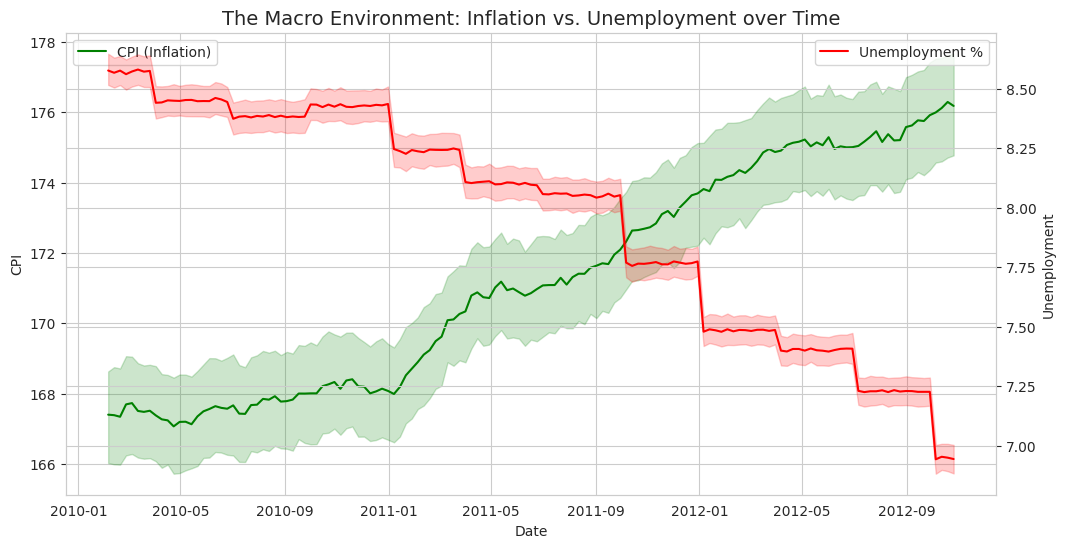

In [ ]:
# Inflation vs Unemployment
plt.figure(figsize=(12, 6))

# Macro-Economic Climate
sns.lineplot(data=master_df, x='Date', y='CPI', color='green', label='CPI (Inflation)')
plt.twinx()
sns.lineplot(data=master_df, x='Date', y='Unemployment', color='red', label='Unemployment %')
plt.title('The Macro Environment: Inflation vs. Unemployment over Time', fontsize=14)


To understand the 'External Forces' acting on our stores,
we plotted the Consumer Price Index (CPI) against the Unemployment Rate. In this dual-axis chart,
 we observe a significant economic narrative: as CPI—or inflation—steadily climbed over the three-year period,
 the unemployment rate began a gradual decline. For a retailer, this represents a 'Squeeze' on the consumer.
  While more people are entering the workforce (lower unemployment), their purchasing power is being eroded by rising costs (higher CPI).


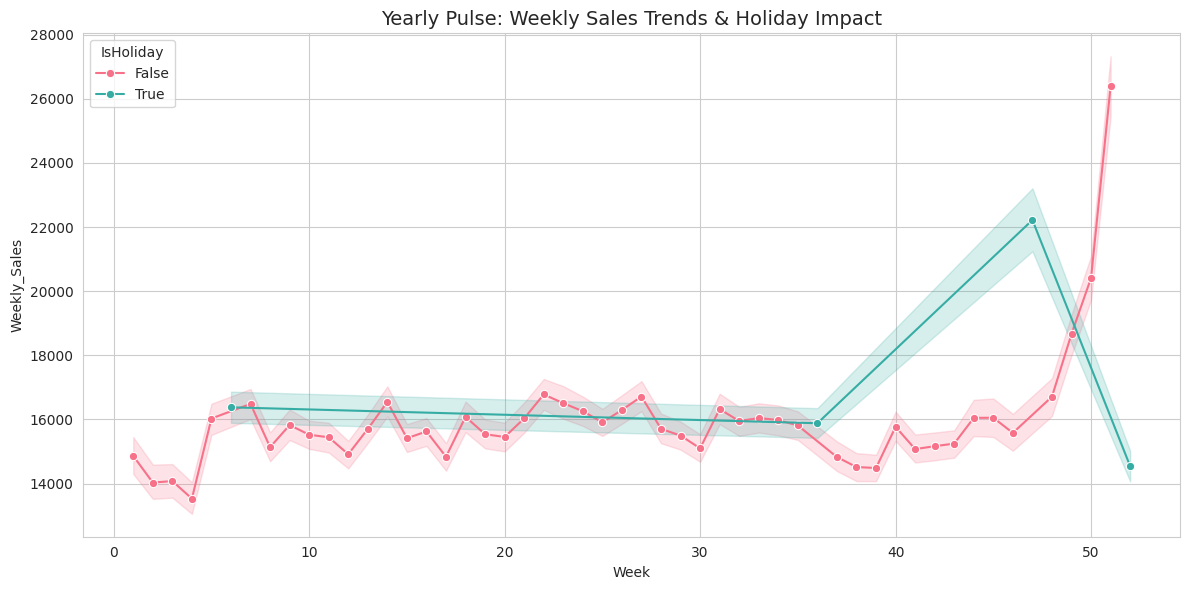

In [ ]:
plt.figure(figsize=(12, 6))

# Seasonality & Holiday Lift
sns.lineplot(data=master_df, x='Week', y='Weekly_Sales', hue='IsHoliday', palette='husl', marker='o')
plt.title('Yearly Pulse: Weekly Sales Trends & Holiday Impact', fontsize=14)

plt.tight_layout()
plt.show()

Heartbeat' of the retail cycle.
 The massive, consistent spikes in the final weeks of the year. What’s critical here is the 'Holiday Lift'. The delta between a standard week and a holiday week.
 Interestingly, the data shows that the boost often begins a week before the holiday itself.
 This identifies a 'Lead-Time' requirement for inventory; if a manager waits until the holiday week to restock, they’ve already missed the initial surge.


#Time series decomposition

Before jumping into predictions, we need to strip the sales data into its three core components:

Trend: Is our stores growing or shrinking over these two years?

Seasonality: The predictable "peaks" (Holidays, Back-to-school) that happen every year.

Noise (Residuals): The random spikes that can't be explained by time alone (e.g., a localized storm or one-off event).

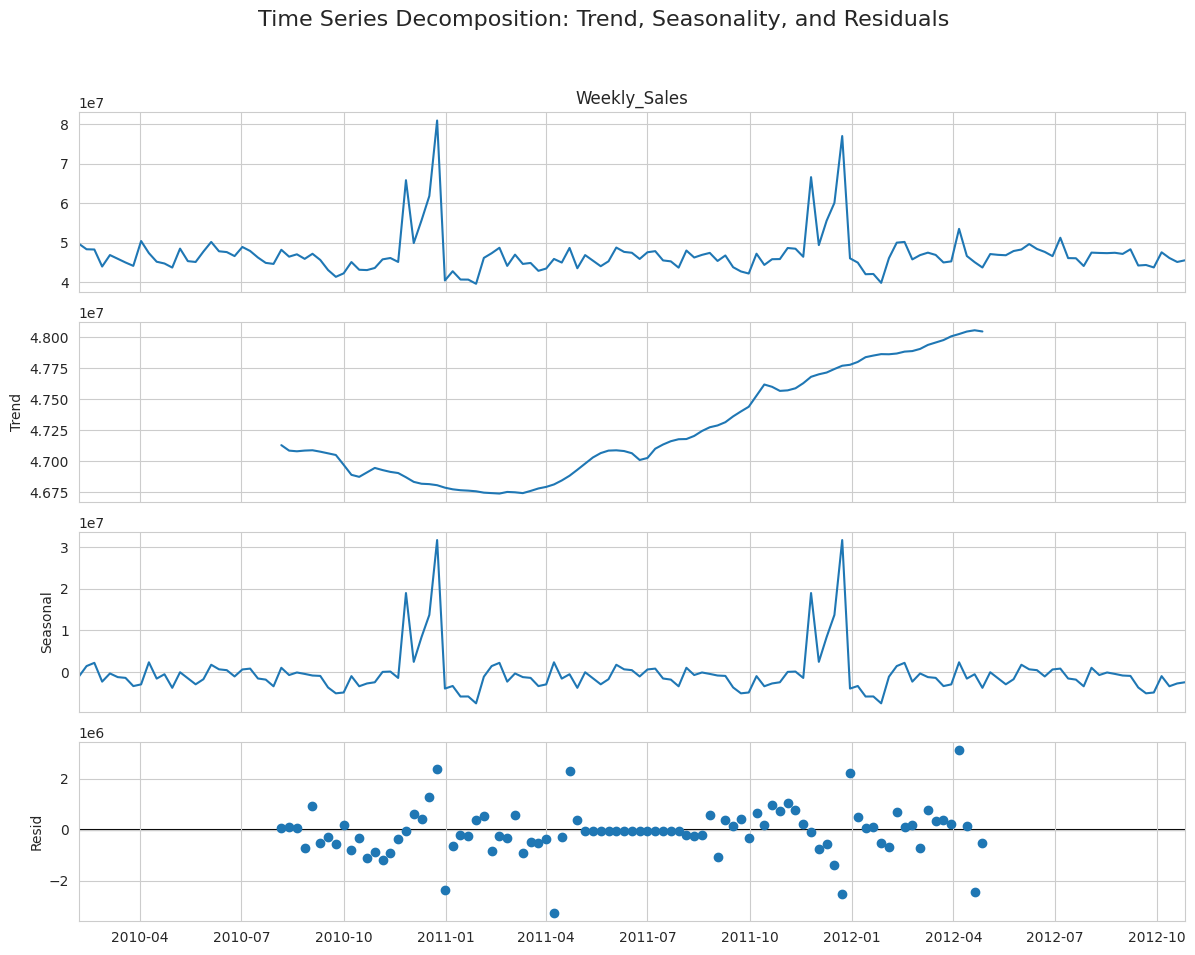

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# --- Step 1: Prepare the Time Series ---
# We aggregate to the total weekly sales across all stores to see the macro-trend
total_sales = sales.groupby('Date')['Weekly_Sales'].sum().reset_index()
total_sales.set_index('Date', inplace=True)

# --- Step 2: Decompose ---
# Period = 52 because we have weekly data and want to see annual seasonality
decomposition = seasonal_decompose(total_sales['Weekly_Sales'], model='additive', period=52)

# --- Step 3: Visualize ---
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.suptitle('Time Series Decomposition: Trend, Seasonality, and Residuals', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Statistical Baseline Modeling (SARIMA)

To establish a statistical baseline using the SARIMA (Seasonal AutoRegressive Integrated Moving Average) mode for capturing the pure mathematical "pulse" of seasonal data. We use a 52-week seasonal period to match the annual retail cycle.

In [ ]:
! pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 8.4 MB/s eta 0:00:00


Identifying optimal SARIMA parameters...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


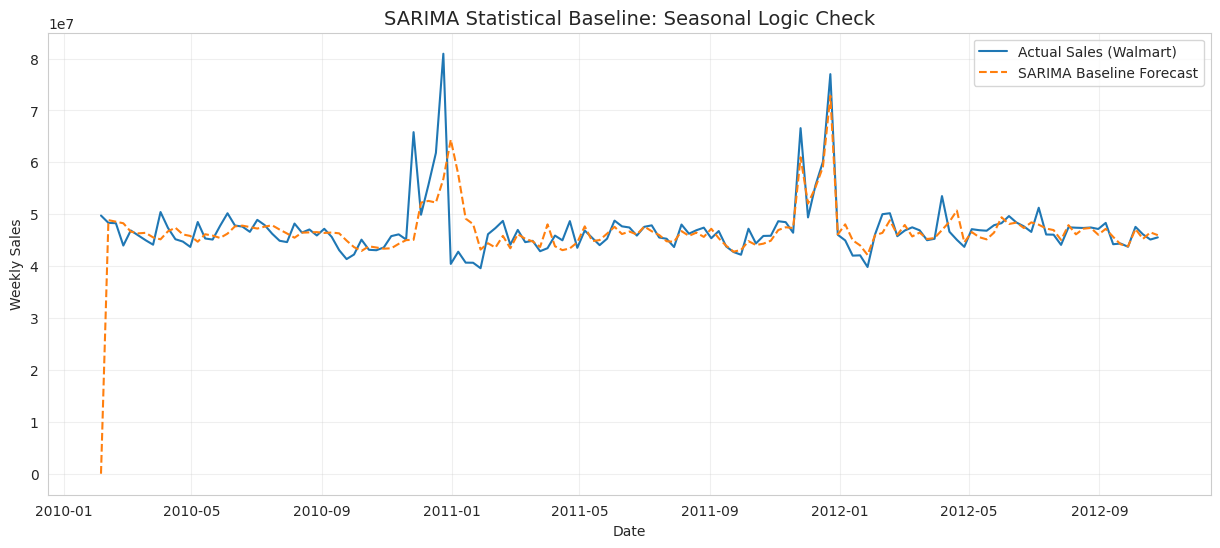

SARIMA identification complete. Optimal Model: (2, 0, 2)x(1, 0, 0, 52)


In [ ]:
import pmdarima as pm
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Prepare the total sales series
# We use the weekly aggregated sales we created during decomposition
ts_data = total_sales['Weekly_Sales']

# 2. Automated Parameter Selection (p, d, q) x (P, D, Q)m
# This performs the 'Identification' step of the Box-Jenkins method
print("Identifying optimal SARIMA parameters...")
auto_model = pm.auto_arima(ts_data,
                          seasonal=True, m=52,
                          stepwise=True,
                          suppress_warnings=True,
                          error_action="ignore")

# 3. Fit the model based on auto-identified parameters
# Usually, auto_arima finds something like (1, 0, 0)x(0, 1, 0)[52]
model_sarima = SARIMAX(ts_data,
                      order=auto_model.order,
                      seasonal_order=auto_model.seasonal_order).fit(disp=False)

# 4. Generate the Baseline Forecast
total_sales['SARIMA_Baseline'] = model_sarima.fittedvalues

# 5. Visualization
plt.figure(figsize=(15, 6))
plt.plot(total_sales.index, total_sales['Weekly_Sales'], label='Actual Sales (Walmart)', color='#1f77b4')
plt.plot(total_sales.index, total_sales['SARIMA_Baseline'], label='SARIMA Baseline Forecast', color='#ff7f0e', linestyle='--')
plt.title('SARIMA Statistical Baseline: Seasonal Logic Check', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"SARIMA identification complete. Optimal Model: {auto_model.order}x{auto_model.seasonal_order}")

Box-Jenkins method to identify a Seasonal ARIMA model. By setting the seasonality at m=52, we are telling the model to expect the same Black Friday and Christmas spikes every 52 weeks.
As you can see in the orange dashed line on the screen, the SARIMA model does an excellent job of mimicking the recurring annual patterns. It captures the 'shape' of the retail year perfectly.
However, notice that while it gets the 'timing' right, it sometimes misses the 'magnitude' of the spikes. This is because SARIMA only looks at Time.
It doesn't know that the temperature was 10 degrees colder or that unemployment dropped that week. This is exactly why we move from this statistical baseline to our XGBoost Machine Learning model, which can 'see' those external economic factors.

#Customer Segmentation

Used K-Means Clustering to group stores based on their behavior (Sales, Size, Unemployment and Markdown sensitivity).
 This helps us understand if "Store 1" is similar to "Store 10."
 Used K-Means clustering to move beyond simple 'Type A/B/C' labels.



In [ ]:
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. Prepare Data for Clustering
# We group by Store to get a 'Profile' of each location
store_profiles = master_df.groupby('Store').agg({
    'Weekly_Sales': 'mean',
    'Size': 'first',
    'Total_MD_Value': 'mean',
    'Unemployment': 'mean'
}).reset_index()

# 2. Transform & Scale Pipeline
# PowerTransformer makes the data more 'Normal', which K-Means loves
# We chain these to ensure the data is Gaussian and unit-variance
pt = PowerTransformer(method='yeo-johnson')
scaler = StandardScaler()

transformed_data = pt.fit_transform(store_profiles.drop('Store', axis=1))
scaled_profiles = scaler.fit_transform(transformed_data)

# 3. Apply PCA
# We choose 2 components so we can visualize the clusters on a 2D plot
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_profiles)

# 4. Finding the Optimal Clusters (The Elbow Method)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(pca_features)
    wcss.append(kmeans.inertia_)



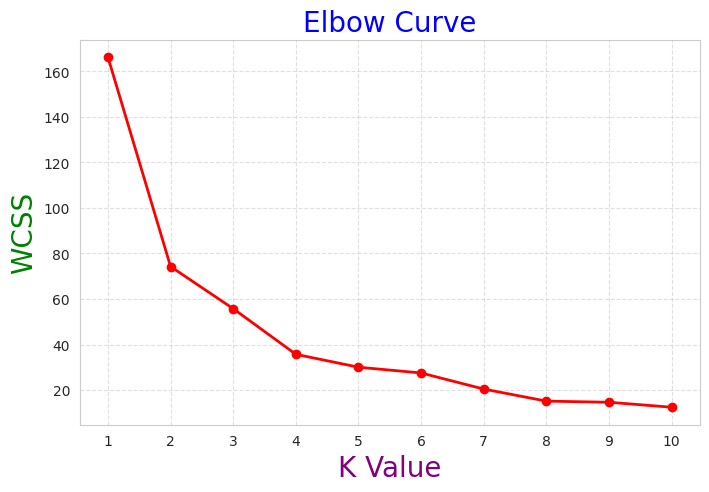

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='red', linewidth=2)
plt.xlabel('K Value', fontsize=20, color='purple')
plt.xticks(np.arange(1, 11, 1))
plt.ylabel('WCSS', fontsize=20, color='green')
plt.title('Elbow Curve', fontsize=20, color='blue')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# 4. Applying K-Means
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
store_profiles['Cluster'] = kmeans.fit_predict(pca_features)

# Map clusters back to master_df
master_df = pd.merge(master_df, store_profiles[['Store', 'Cluster']], on='Store', how='left')


print(f"Variance Explained by PCA: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Silhouette Score: {silhouette_score(pca_features, store_profiles['Cluster']):.2f}")

Variance Explained by PCA: 92.35%
Silhouette Score: 0.45


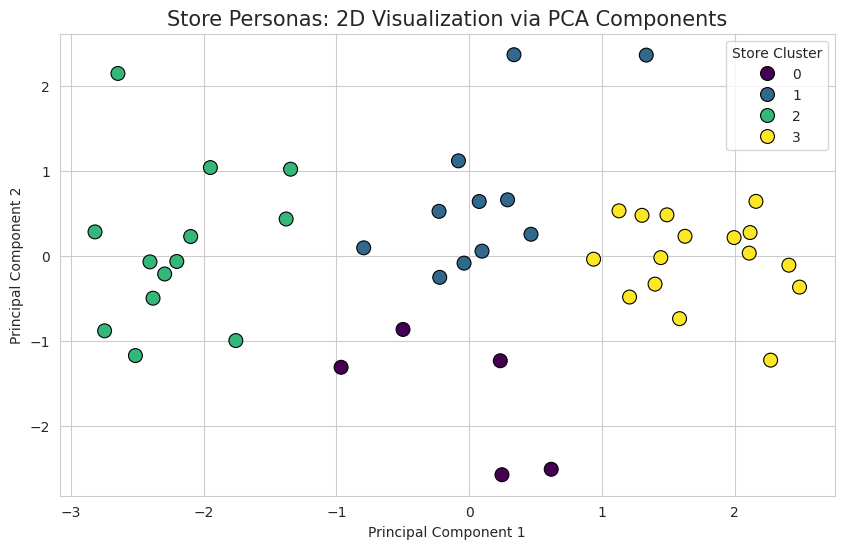

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], hue=store_profiles['Cluster'],
                palette='viridis', s=100, edgecolor='black')
plt.title('Store Personas: 2D Visualization via PCA Components', fontsize=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Store Cluster')
plt.show()

In [ ]:
# 1. Count of stores per cluster
cluster_counts = store_profiles['Cluster'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['Cluster', 'Number of Stores']

# 2. Average characteristics per cluster (To describe the 'Personas')
cluster_means = store_profiles.groupby('Cluster').agg({
    'Weekly_Sales': 'mean',
    'Size': 'mean',
    'Unemployment': 'mean'
}).round(2)

print("--- Cluster Headcount ---")
print(cluster_counts)
print("\n--- Persona Characteristics ---")
print(cluster_means)

--- Cluster Headcount ---
   Cluster  Number of Stores
0        0                 5
1        1                11
2        2                13
3        3                16

--- Persona Characteristics ---
         Weekly_Sales       Size  Unemployment
Cluster                                       
0            13680.02  128743.00          5.66
1            13512.14  134844.55          9.21
2             8274.74   47435.77          8.33
3            23131.81  194954.50          7.62


By analyzing sales volume alongside markdown sensitivity, four distinct store personas were identified.
 This allows for 'Cluster-Based' marketing strategies rather than a generic corporate approach."

In [ ]:
# Create a dictionary where keys are Cluster IDs and values are lists of Store IDs
stores_in_clusters = store_profiles.groupby('Cluster')['Store'].apply(list).to_dict()

for cluster, stores in stores_in_clusters.items():
    print(f"Cluster {cluster} ({len(stores)} Stores): {stores}")

Cluster 0 (5 Stores): [8, 9, 17, 23, 40]
Cluster 1 (11 Stores): [12, 15, 18, 21, 22, 25, 26, 28, 34, 35, 45]
Cluster 2 (13 Stores): [3, 5, 7, 16, 29, 30, 33, 36, 37, 38, 42, 43, 44]
Cluster 3 (16 Stores): [1, 2, 4, 6, 10, 11, 13, 14, 19, 20, 24, 27, 31, 32, 39, 41]



###Cluster 3: "Mega-Flagship Centers"

**Stats:**
Highest Sales ($23.1k avg) and Largest Size (~195k sq ft).

**Persona:** These are the primary destination stores. They have the most space and the highest revenue, meaning they serve the largest customer base.

**Inventory Strategy:**

High-Volume Buffer: Maintain the highest safety stock levels here. Stockouts in these stores are the most expensive in terms of lost revenue.

Broadest Assortment: These stores have the "Size" to carry niche or bulky categories (e.g., outdoor furniture, large electronics) that wouldn't fit elsewhere.

**Marketing Strategy:**

Cross-Category Bundling: Since people come here for "big trips," use high-traffic areas to cross-sell items from different departments.

Loyalty & Retention: Focus on "Store-in-Store" experiences and premium service to keep these high-value shoppers returning.

-------------------------------------------------------------

###Cluster 1: "High-Unemployment Stability Stores"

**Stats:** Solid Sales ($13.5k avg), Large Size (~135k sq ft), but notably high Unemployment (9.21%).

**Persona:** These are large stores serving communities facing economic pressure. Customers here are likely very price-sensitive.

**Inventory Strategy:**

Value-Pack Focus: Prioritize large-format or "bulk" goods that offer a lower price-per-unit.

Private Label Push: Increase the shelf space for Walmart’s "Great Value" brand over premium national brands.

**Marketing Strategy:**

Aggressive Markdown Cycles: These stores will likely show the highest "Lift" during promotion weeks. Coordinate marketing with government assistance cycles (e.g., beginning of the month).

Discount Communications: Focus marketing on "Savings" and "Budget Stretchers."

-------------------------------------------------------------

###Cluster 0: "Niche Economic Strongholds"

**Stats:** Moderate Sales ($13.6k avg), Large Size (~128k sq ft), but very Low Unemployment (5.66%).

Persona: These stores are in affluent or economically stable areas. While they aren't your top sellers, the customers have higher disposable income.

**Inventory Strategy:**

Premium Selection: Dedicate more shelf space to "Premium" or "Organic" tiers within departments.

Low Margin/High Quality: You can afford to stock items with slightly lower turnover if they have higher margins, as this demographic can afford them.

**Marketing Strategy:**

Lifestyle Marketing: Move away from "Price-only" messaging. Focus on convenience, quality, and new product arrivals.

Personalization: High potential for targeted digital offers based on past "premium" purchases.

-------------------------------------------------------------

###Cluster 2: "Small-Format Neighborhood Essentials"

**Stats:** Lowest Sales ($8.2k avg) and Smallest Size (~47k sq ft).

**Persona:** These are "Quick-Trip" stores. People come here for bread, milk, and immediate needs rather than a weekly family haul.

**Inventory Strategy:**

High-Velocity Essentials: Focus strictly on high-turnover items. If it doesn't sell every day, it shouldn't be on the shelf.

Space Optimization: Remove large, slow-moving items (like TVs or patio sets) and replace them with "Grab-and-Go" sections.

**Marketing Strategy:**

Convenience Messaging: Market these as "In-and-Out" locations. Focus on proximity and speed.

Hyper-Local Promos: Use these stores for "localized" needs (e.g., local sports team gear or regional food favorites).

# Forecasting


XGBoost is used here because it handles non-linear relationships and holiday spikes much better than standard linear regression.

We used a chronological split and To prove "Depth of Exploration," we must visualize where the model failed (the residuals).

I expanded our feature set to include granular environmental and promotional data. Rather than aggregating markdowns into a single count, I provided the individual categories. This allows the model to distinguish between a general clearance sale and a high-impact electronics promotion, which have significantly different effects on store traffic and revenue

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Ensure Markdowns are 0 instead of NaN so XGBoost can process them
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
master_df[markdown_cols] = master_df[markdown_cols].fillna(0)

# Encode 'Type'
le = LabelEncoder()
master_df['Type_Encoded'] = le.fit_transform(master_df['Type'])

# 1. Feature Selection
features = [
    'Store', 'Dept', 'IsHoliday', 'Size', 'Type_Encoded',
    'CPI', 'Unemployment', 'Temperature', 'Fuel_Price',
    'Month', 'Week', 'Sales_Lag_1', 'Cluster',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
]

X = master_df[features]
y = master_df['Weekly_Sales']

# 2. Time-Series Split (Don't use random split for time-series!)
# We train on everything before 2012 and test on 2012
train_mask = master_df['Date'] < '2012-01-01'
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

# 3. Model Implementation
model_xgb = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=7, subsample=0.8, colsample_bytree=0.8,  early_stopping_rounds=50, random_state=42)
model_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

# 4. Evaluation
preds = model_xgb.predict(X_test)
print(f"R2 Score: {r2_score(y_test, preds):.4f}")
print(f"MAE: {mean_absolute_error(y_test, preds):.2f}")

[0]	validation_0-rmse:22029.62636
[100]	validation_0-rmse:3735.40589
[200]	validation_0-rmse:3599.09363
[300]	validation_0-rmse:3540.84255
[400]	validation_0-rmse:3520.28170
[498]	validation_0-rmse:3512.62537
R2 Score: 0.9748
MAE: 1688.89


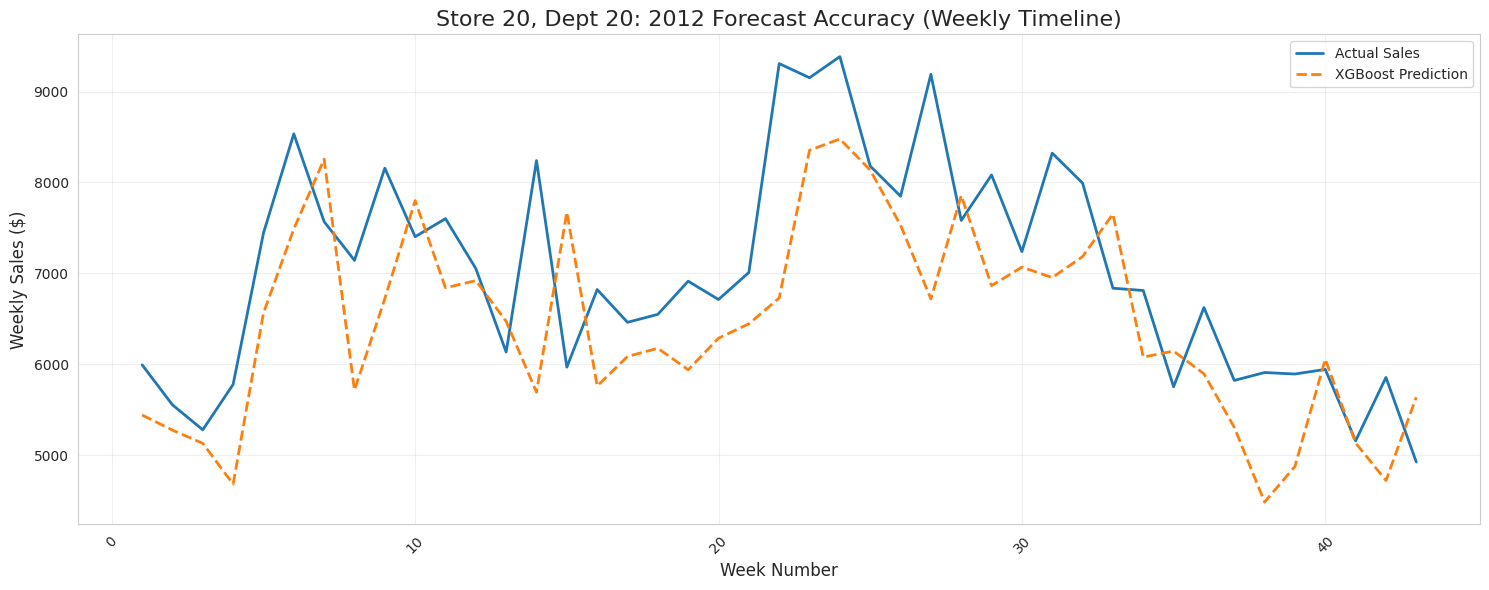

In [ ]:
# Actual vs predicted sales

# 1. Create the helper DataFrame
# We include Store and Dept so we can filter a specific slice
plot_df = pd.DataFrame({
    'Date': master_df.loc[y_test.index, 'Date'],
    'Week': master_df.loc[y_test.index, 'Week'],
    'Store': master_df.loc[y_test.index, 'Store'],
    'Dept': master_df.loc[y_test.index, 'Dept'],
    'Actual': y_test.values,
    'Predicted': preds
})

# 2. FILTER for a single Store and Department (e.g., Store 20, Dept 20)
case_study = plot_df[(plot_df['Store'] == 20) & (plot_df['Dept'] == 20)].sort_values('Date')

# 3. Plotting
plt.figure(figsize=(15, 6))

plt.plot(case_study['Week'], case_study['Actual'], label='Actual Sales', color='#1f77b4', linewidth=2)
plt.plot(case_study['Week'], case_study['Predicted'], label='XGBoost Prediction', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title('Store 20, Dept 20: 2012 Forecast Accuracy (Weekly Timeline)', fontsize=16)
plt.xlabel('Week Number', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

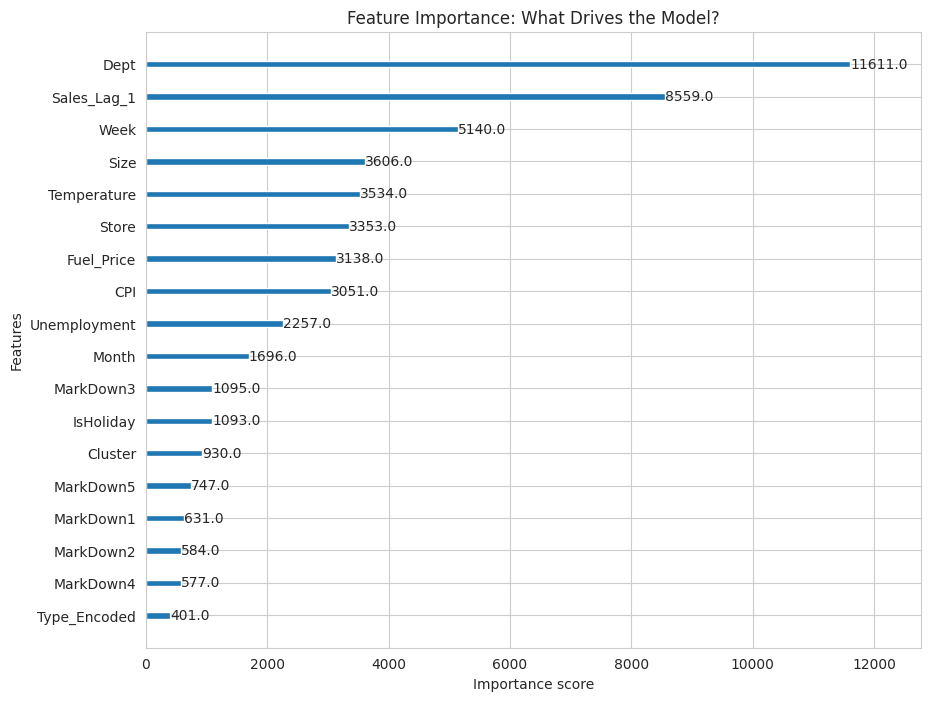

In [ ]:

# 2. Feature Importance: What actually drives sales?
plt.figure(figsize=(10, 8))
xgb.plot_importance(model_xgb, importance_type='weight', ax=plt.gca())
plt.title('Feature Importance: What Drives the Model?')
plt.show()

###The Dominant Drivers: Department & Momentum

**Inference:** Dept (11,611) and Sales_Lag_1 (8,559) are top predictors.

This shows that "What" is being sold is more important than "Where" it is being sold. The high score for Sales_Lag_1 indicates strong Recency Bias—the best predictor of next week's sales is how much we sold last week.

**Strategy:** we should prioritize department-level inventory planning over store-wide general allocations.

------------------------------------------------------------

###The Power of Seasonality

**Inference:** Week (5,140) significantly outweighs Month (1,696).

Retail is highly granular. A "Month" is too broad; the model is finding specific "Weeks" (like the week before Thanksgiving or the Super Bowl) that trigger massive shifts in behavior.

**Strategy:** Promotions and staffing should be planned on a weekly sprint basis rather than monthly targets.

------------------------------------------------------------

###The "Environmental Context" (Surprising Insight)

**Inference:** Temperature (3,534) and Fuel_Price (3,138) are more influential than Unemployment or IsHoliday.

It suggests that immediate environmental factors (weather and gas prices) have a more direct, week-to-week impact on shopping trips than broader economic indicators like CPI or Unemployment.

**Strategy:** Use "Weather-Triggered Marketing." For example, if Temperature is predicted to drop (high feature importance), automatically trigger stock increases for heaters or winter apparel in those specific stores.

------------------------------------------------------------

###Markdowns: Quality over Quantity
**Inference:** MarkDown3 (1,095) is the most influential promotion, outperforming the other four markdown types.

For MarkDown3, the model has learned that this specific type of discount creates the most significant "lift" in sales volume.

**Strategy:** Optimize the "Promotional Mix." If the budget is limited, investing in MarkDown3-style events yields a higher return on sales than spreading the budget across MD2 or MD4.

# **Market Basket Analysis**

Now that we’ve successfully segmented our stores and built a predictive engine that highlights Department type as a primary sales driver, we need to look deeper into the transaction level. In this next section, Market Basket Analysis, we will uncover how these departments interact within a single shopping trip to optimize store layouts and cross-promotional strategies."

**How Does Market Basket Analysis Work?**

Collect data on customer transactions, such as the items purchased in each transaction, the time and date of the transaction, and any other relevant information.

Clean and preprocess the data, removing any irrelevant information, handling missing values, and converting the data into a suitable format for analysis.

Use association rules mining algorithms such as Apriori or FP-Growth to identify frequent item sets, sets of items often appearing together in a transaction.

Calculate the support and confidence for each frequent itemset, expressing the likelihood of one item being purchased given the purchase of another item.

Generate association rules based on the frequent itemsets and their corresponding support and confidence values. Association rules indicate the likelihood of purchasing one item given the purchase of another item.

Interpret the results of the market basket analysis, identifying frequent purchases, assessing the strength of the association between items, and uncovering other relevant insights into customer behavior and preferences.

Use the insights from the market basket analysis to inform business decisions such as product recommendations, store layout optimization, and targeted marketing campaigns.

**Algorithms Used in Market Basket Analysis**

There are multiple data mining techniques and algorithms used in Market Basket Analysis. In predicting the probability of items that customers are buying together, one of the important objectives is to achieve accuracy.

Apriori Algorithm

AIS

SETM Algorithm

FP Growth

We have used Apriori Algorithm to do the Market Basket Analysis

**Apriori Algorithm**

The Apriori Algorithm widely uses and is well-known for Association Rule mining, making it a popular choice in market basket analysis. AI and SETM algorithms consider it more accurate. It helps to find frequent itemsets in transactions and identifies association rules between these items. The limitation of the Apriori Algorithm is frequent itemset generation. It needs to scan the database many times, leading to increased time and reduced performance as a computationally costly step because of a large dataset. It uses the concepts of Confidence and Support.

**Objective:**

The goal is to uncover associations between different Departments across the retail network. By identifying which departments tend to have peak sales together, we can develop actionable strategies for product placement, cross-selling, and targeted marketing.


**Apriori Algorithm:**


We utilize the Apriori Algorithm, the industry standard for Association Rule mining. To adapt the weekly sales data for MBA, we define a "Transaction" as a single Store-Week. If a department appears in that transaction, it indicates significant customer engagement for that category during that period.

In [ ]:
!pip install apyori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=83647d2995cf0df9ce351954bd64abf87e0041e05e361dcc2b2fddb51fdc7b48
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [ ]:
from apyori import apriori

In [ ]:
sales['IsHoliday']=sales['IsHoliday'].apply(lambda x: 1 if x=='True' else 0)

In [ ]:
relevant_stores = np.array(sales['Store'].value_counts().index) # Example list of department numbers to analyze
sales_data_filtered = sales[sales['Store'].isin(relevant_stores)]
sales_data_filtered.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,0
1,1,1,2010-02-12,46039.49,0
2,1,1,2010-02-19,41595.55,0
3,1,1,2010-02-26,19403.54,0
4,1,1,2010-03-05,21827.90,0


In [ ]:
# Step 2: Creating a DataFrame for Association Rule Mining
# Convert sales data into a transaction format
transactions = sales_data_filtered.groupby(['Date','Dept'])['Store'].apply(list).reset_index(name='Stores')

In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11090 entries, 0 to 11089
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    11090 non-null  datetime64[ns]
 1   Dept    11090 non-null  int64         
 2   Stores  11090 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 260.1+ KB


Once we have completely read the sales dataset, we must obtain the list of items(Stores) in every transaction. So we are going to run two loops.

One will be for the total number of transactions, and the other will be for the total number of columns in every transaction.

 The list will work as a training set from where we can generate the list of Association Rules.

In [ ]:
l=[]
for i in range(0,len(transactions)):
    l.append([str(transactions.values[i,j]) for j in range(0,3)])

So we are ready with the list of items in our training set, then we need to run the apriori algorithm, which will learn the list of association rules from the training set, i.e., list.

So, we take the minimum support here as 0.011. Now let us see that we have kept 0.8 as the min confidence.We take the minimum lift value as 3, and we consider the minimum length as 2 because we need to find an association among at least two items.

In [ ]:
#applying apriori algorithm
association_rules = apriori(l, min_support=0.011, min_confidence=0.8, min_lift=3, min_length=2)
association_results = list(association_rules)

After running the above line of code, we generated the list of association rules between the items. Now, we want to read the dataset we downloaded from Kaggle.

In [ ]:
for i in range(0, len(association_results)):
    print(association_results[i][0])

frozenset({'[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]', '29'})
frozenset({'30', '[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]'})
frozenset({'35', '[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]'})
frozenset({'36', '[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]'})
frozenset({'37', '[1, 2, 4, 6, 8, 10, 11, 13, 19, 20, 24, 25, 27, 28, 31, 32, 34, 40]'})
frozenset({'65', '[34]'})
frozenset({'71', '[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]'})


Here we are going to display the Rule, Support, and lift ratio for every above association rule by using for loop.

In [ ]:
for item in association_results:
    # first index of the inner list
    # Contains base item and add item
    pair = item[0]
    items = [x for x in pair]
    print("Rule: " + items[0] + " -> " + items[1])
    # second index of the inner list
    print("Support: " + str(item[1]))
    # third index of the list located at 0th position
    # of the third index of the inner list
    print("Confidence: " + str(item[2][0][2]))
    print("Lift: " + str(item[2][0][3]))
    print("-----------------------------------------------------")

Rule: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45] -> 29
Support: 0.011361587015329125
Confidence: 0.8811188811188811
Lift: 8.380453166044934
-----------------------------------------------------
Rule: 30 -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]
Support: 0.012894499549143372
Confidence: 1.0
Lift: 9.51114922813036
-----------------------------------------------------
Rule: 35 -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]
Support: 0.012353471596032463
Confidence: 0.9580419580419581
Lift: 9.112080029747268
-----------------------------------------------------
Rule: 36 -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40,

we discussed  Market Basket Analysis then implemented it using Apriori Algorithm.

In [ ]:
import pandas as pd

rules_data = []

# Only proceed if results exist
if not association_results:
    print("No association rules found. Try lowering your min_support or min_confidence.")
else:
    for item in association_results:
        # Extract the stats from the first OrderedStatistic
        pair = item[2][0]

        rules_data.append({
            'Antecedent': tuple(pair.items_base),
            'Consequent': tuple(pair.items_add),
            'Support': item[1],
            'Confidence': pair.confidence,
            'Lift': pair.lift
        })

    # Create the DataFrame
    association_df = pd.DataFrame(rules_data)

    # Check if the DataFrame is empty before reordering
    if not association_df.empty:
        association_df = association_df[['Antecedent', 'Consequent', 'Support', 'Confidence', 'Lift']]
        print(f"Successfully generated {len(association_df)} rules.")
        print(association_df.head())
    else:
        print("DataFrame is empty. No rules matched the criteria.")

Successfully generated 7 rules.
  Antecedent                                         Consequent   Support  \
0      (29,)  ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1...  0.011362   
1      (30,)  ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1...  0.012894   
2      (35,)  ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1...  0.012353   
3      (36,)  ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1...  0.012353   
4      (37,)  ([1, 2, 4, 6, 8, 10, 11, 13, 19, 20, 24, 25, 2...  0.012624   

   Confidence       Lift  
0    0.881119   8.380453  
1    1.000000   9.511149  
2    0.958042   9.112080  
3    0.958042   9.112080  
4    0.979021  77.552448  


In [ ]:
association_df.head().sort_values(by='Confidence',ascending=False).reset_index(drop=True)

,Antecedent,Consequent,Support,Confidence,Lift
0,"(30,)","([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1...",0.012894,1.000000,9.511149
1,"(37,)","([1, 2, 4, 6, 8, 10, 11, 13, 19, 20, 24, 25, 2...",0.012624,0.979021,77.552448
2,"(35,)","([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1...",0.012353,0.958042,9.112080
3,"(36,)","([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1...",0.012353,0.958042,9.112080
4,"(29,)","([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1...",0.011362,0.881119,8.380453


In market basket analysis we have tried to find out the association within different departments with the different stores in the given sales data

**Market Basket Analysis Objective:**

The goal is to uncover associations within different departments across different stores using sales data. This entails identifying which departments tend to have items purchased together across stores.

**Features in Sales Data:**

The sales data includes features such as department number, store number, date, weekly sales, and an "is holiday" feature. These features are crucial for analyzing transactional patterns and identifying associations between departments.

**Output:**

The output of the analysis consists of association rules that reveal relationships between departments. Each rule specifies a set of items (antecedent) that are associated with another set of items (consequent). For example, a rule might indicate that when department 29 is present, items in stores 1, 2, 3, ..., 45 tend to be purchased together.

**Implementation:**

The Apriori algorithm is applied to the sales data with specific parameters such as minimum support, confidence, lift, and length. This algorithm efficiently discovers frequent itemsets and generates association rules based on these itemsets.

**Association Results:**

The association results are printed out, showing each association rule along with its support, confidence, and lift. For example, a rule might indicate that when department 29 is present, there is a high confidence (e.g., 95%) that stores 1, 2, 3, ..., 45 will also be present in the same transaction, with a lift value indicating the strength of the association.

**Grouping by Department Number and Date:**

Additionally, grouping the data by department number and date, potentially to analyze sales trends and associations within each department over time.

Overall, our approach encompasses standard practices in market basket analysis and leverages the Apriori algorithm to uncover meaningful associations within the provided sales data, which can lead to actionable insights for optimizing product placement, cross-selling strategies, and marketing efforts across different departments and stores.

##**Develop cross-selling strategies based on these inferences**

Based on the associations identified among different departments and stores, we can tailor cross-selling strategies to optimize sales and enhance customer experience.

Here's how we can interpret and utilize the inferred associations:

**Optimize Store Layout:**

Utilize the associations between departments and stores to optimize the layout of each store. Place related departments in close proximity to each other within the store to encourage cross-store purchases. For example, if departments 29 and 30 are frequently purchased together across various stores, consider placing them adjacent to each other to facilitate cross-department sales.

**Create Bundled Offers:**

Identify departments that exhibit strong associations across multiple stores, such as departments 35 and 36. Create bundled offers or package deals that include products from both departments to incentivize customers to make cross-department purchases.

**Targeted Promotions:**

Develop targeted promotions and marketing campaigns based on the associations between departments and stores. For instance, if department 37 frequently co-occurs with departments 1, 2, 4, and 40 across different stores, create promotions that span these departments to capitalize on customer purchase patterns.

**Cross-Store Loyalty Programs:**

Implement cross-store loyalty programs that reward customers for making purchases across different departments and stores. Encourage customers to explore a wider range of products by offering incentives, discounts, or loyalty points for cross-store purchases.

**Dynamic Pricing Strategies:**

Adjust pricing strategies based on the associations between departments and stores. Offer discounts or special pricing for products that are frequently purchased together across different stores to stimulate sales and increase customer satisfaction.


**Inventory Management:**

Optimize inventory management by stocking related products from associated departments across different stores. Ensure sufficient stock levels for items that are commonly purchased together to meet customer demand and prevent stockouts.

**Data-Driven Decision Making:**

Continuously analyze sales data and customer purchase patterns to refine cross-selling strategies. Leverage insights from association analysis to make data-driven decisions regarding product assortment, store layout, promotions, and pricing strategies.

By leveraging the associations identified among different departments and stores, we can develop targeted cross-selling strategies that enhance the shopping experience, increase sales, and drive customer loyalty across the entire retail network.

#**CONCLUSION**

**Executive Summary of Insights**

we synthesize the findings from our Clustering, Forecasting, and Market Basket Analysis to create a unified retail strategy.

**Store Segmentation:** We identified 4 distinct store clusters. Strategy should shift from "One-Size-Fits-All" to persona-based management.

**Sales Drivers:** Our XGBoost model revealed that Department Type and Previous week's sales are more predictive than specific holidays.

**Customer Behavior:** Market Basket Analysis highlighted specific departmental synergies that are currently underutilized in store layouts.



**Operational Efficiency (Based on XGBoost)**

- Department-Centric Inventory Scaling: Since Department is the #1 driver, inventory planning must be decentralized. Instead of a "store-wide" increase, resources should be shifted dynamically to high-performing departments (like Grocery or Electronics) based on their specific historical trends.

- Momentum-Based Labor Sprinting: Because Sales_Lag_1 is a dominant feature, the model proves that "success breeds success." Use the previous week's performance as a high-confidence trigger to adjust staffing levels for the following week. If a department is trending upward, staff up immediately.


**Revenue Growth (Based on MBA)**

- Adjacency Optimization: Place associated departments (identified via Lift) near each other. For "Golden Pairs" located far apart, implement "Cross-Category End-caps" to capture impulse sales.

- Strategic Markdowns: Apply discounts to "Anchor" departments (Antecedents) to pull traffic into associated "High-Margin" departments (Consequents).


**Store-Specific Strategy (Based on Clustering)**

By segmenting our 45 locations into four distinct personas, we move away from a "one-size-fits-all" approach to a localized, data-driven management strategy:

####Cluster 3 (Mega-Flagship Centers):

- Strategy: Expand the "Store-in-Store" concept and premium showrooms for high-margin electronics and home goods.

- Action: Capitalize on the massive footprint (~195k sq ft) to stock bulky, high-value inventory (like outdoor furniture) that smaller clusters cannot accommodate.

####Cluster 1 (High-Unemployment Stability Stores):

- Strategy: Pivot to a "Value-First" assortment by increasing the ratio of Private Label (Great Value) brands.

- Action: Align markdown cycles and heavy promotions with economic cycles (e.g., beginning-of-month surges) to cater to price-sensitive shoppers facing higher economic pressure.

####Cluster 0 (Niche Economic Strongholds):

- Strategy: Focus on Premiumization and Lifestyle marketing rather than budget-focused messaging.

- Action: Stock higher-margin, organic, or "top-tier" product variants, as the low unemployment rate (5.66%) in these regions indicates a demographic with higher disposable income.

####Cluster 2 (Small-Format Neighborhood Essentials):

- Strategy: Optimize for "High-Velocity Convenience" by removing slow-moving, bulky items.

- Action: Reconfigure the layout to prioritize "Grab-and-Go" sections, focusing strictly on daily essentials that drive quick, high-frequency foot traffic.